# YouTube Hate Speech Detector
## Proyecto NLP — Detección de mensajes de odio

**Objetivo:** Construir un modelo de clasificación de texto capaz de identificar comentarios
de odio en YouTube, con control de overfitting y una interfaz de uso práctico.

**Dataset:** `youtoxic_english_1000.csv` — 1000 comentarios en inglés etiquetados.

**Flujo del notebook:**
1. Carga y exploración de datos (EDA)
2. Preprocesamiento de texto
3. Vectorización
4. Entrenamiento y evaluación del modelo
5. Ajuste de hiperparámetros
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import warnings

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
nltk.download('stopwords')
nltk.download('wordnet')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Coder\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Coder\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Carga de datos

Cargamos el dataset crudo desde la carpeta `data/raw/`. 
A partir de aquí solo trabajamos sobre copias, nunca modificamos el archivo original.

In [2]:
df = pd.read_csv('../data/raw/youtoxic_english_1000.csv')
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (1000, 15)


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


### Exploración inicial de columnas

Revisamos los nombres de las columnas y los tipos de datos para entender la estructura del dataset.

In [3]:
print(df.columns.tolist())
print("\n")
print(df.dtypes)

['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']


CommentId           str
VideoId             str
Text                str
IsToxic            bool
IsAbusive          bool
IsThreat           bool
IsProvocative      bool
IsObscene          bool
IsHatespeech       bool
IsRacist           bool
IsNationalist      bool
IsSexist           bool
IsHomophobic       bool
IsReligiousHate    bool
IsRadicalism       bool
dtype: object


## 3. Análisis Exploratorio de Datos (EDA)

Exploramos la distribución de las etiquetas, valores nulos y características generales
del texto antes de cualquier transformación.

In [4]:
# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
CommentId          0
VideoId            0
Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsHomophobic       0
IsReligiousHate    0
IsRadicalism       0
dtype: int64


Distribución de IsToxic:
IsToxic
False    538
True     462
Name: count, dtype: int64

Porcentaje de comentarios tóxicos: 46.20%


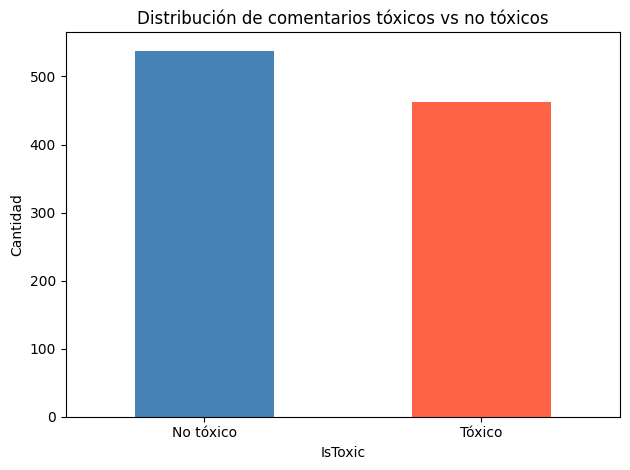

In [5]:
# Distribución de la variable objetivo
print("Distribución de IsToxic:")
print(df['IsToxic'].value_counts())
print(f"\nPorcentaje de comentarios tóxicos: {df['IsToxic'].mean()*100:.2f}%")

df['IsToxic'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distribución de comentarios tóxicos vs no tóxicos')
plt.xticks([0, 1], ['No tóxico', 'Tóxico'], rotation=0)
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

### Distribución de todas las etiquetas

Visualizamos la frecuencia de cada tipo de contenido tóxico para entender
qué categorías predominan en el dataset.

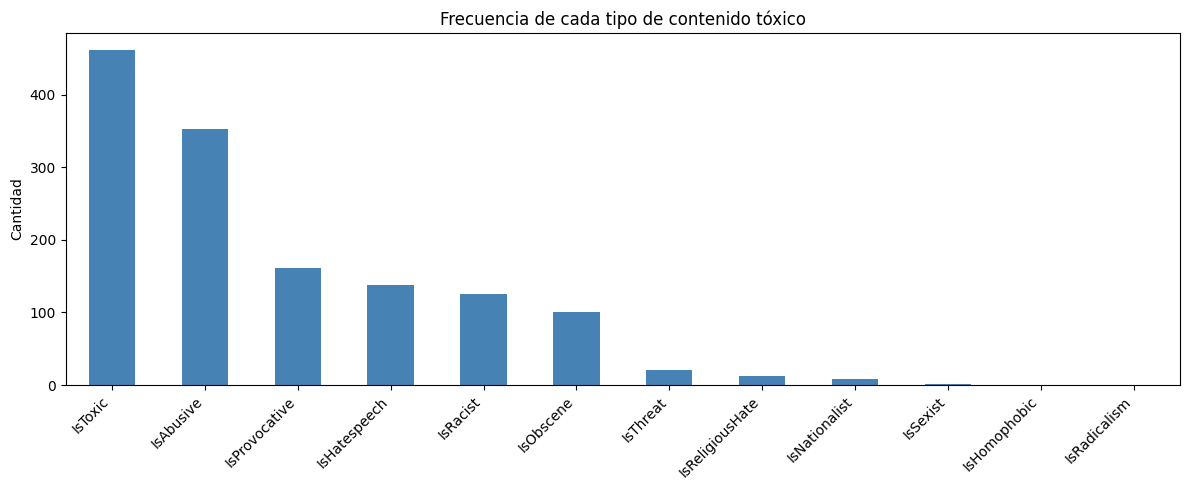

In [6]:
label_cols = ['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene',
              'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
              'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

label_counts = df[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar', color='steelblue')
plt.title('Frecuencia de cada tipo de contenido tóxico')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Longitud de los comentarios

Analizamos la longitud de los textos para detectar outliers y entender
la distribución del contenido.

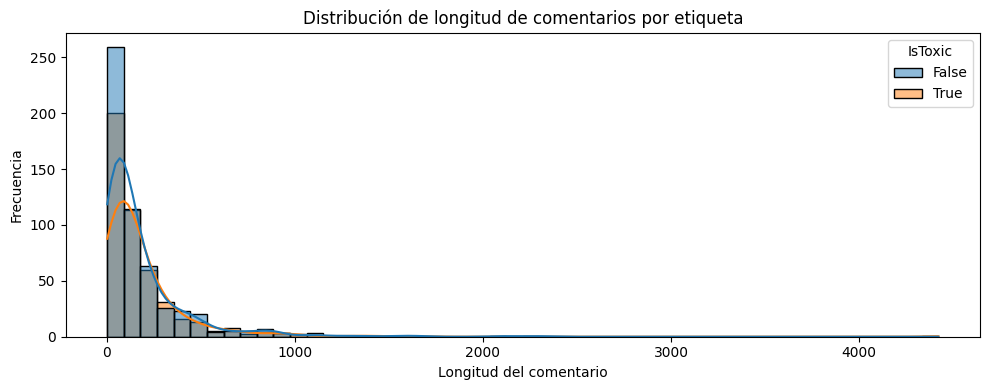

         count        mean         std  min    25%    50%     75%     max
IsToxic                                                                  
False    538.0  182.262082  252.295702  3.0  44.00   96.0  210.75  2292.0
True     462.0  189.387446  291.061941  6.0  54.25  110.0  220.75  4421.0


In [7]:
df['text_length'] = df['Text'].apply(len)

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='text_length', hue='IsToxic', bins=50, kde=True)
plt.title('Distribución de longitud de comentarios por etiqueta')
plt.xlabel('Longitud del comentario')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(df.groupby('IsToxic')['text_length'].describe())

### Wordcloud

Visualizamos las palabras más frecuentes en comentarios tóxicos y no tóxicos
para identificar patrones léxicos antes del preprocesamiento.

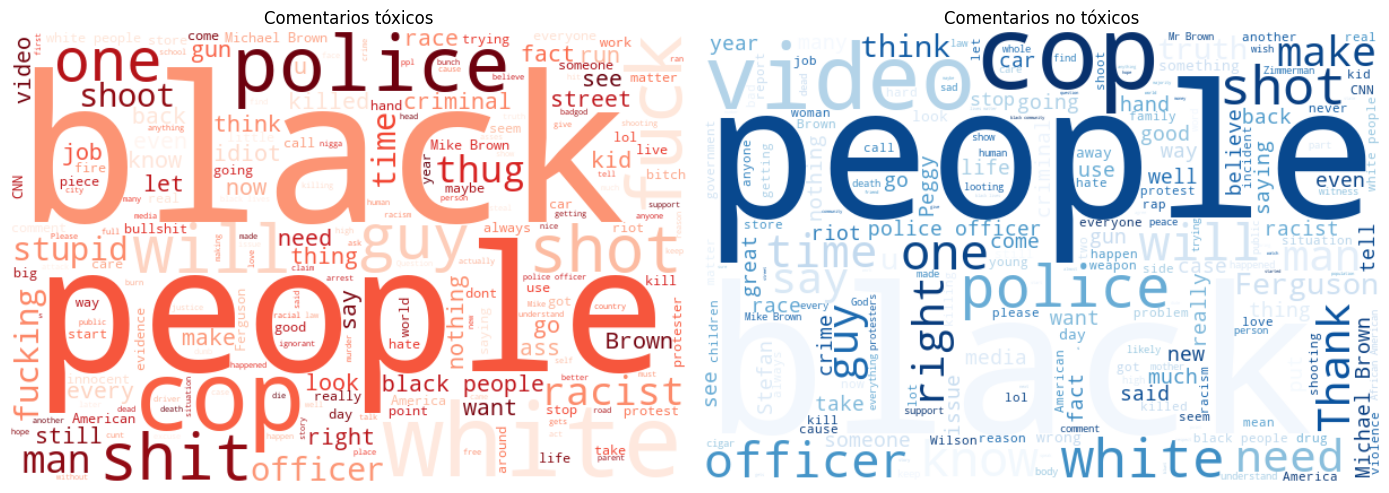

In [8]:
from wordcloud import WordCloud

toxic_text = ' '.join(df[df['IsToxic'] == True]['Text'].astype(str))
clean_text = ' '.join(df[df['IsToxic'] == False]['Text'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_toxic = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(toxic_text)
axes[0].imshow(wc_toxic, interpolation='bilinear')
axes[0].set_title('Comentarios tóxicos')
axes[0].axis('off')

wc_clean = WordCloud(width=600, height=400, background_color='white', colormap='Blues').generate(clean_text)
axes[1].imshow(wc_clean, interpolation='bilinear')
axes[1].set_title('Comentarios no tóxicos')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Matriz de correlación entre etiquetas

Analizamos cómo se relacionan los distintos tipos de contenido tóxico entre sí.
Correlaciones altas indican que ciertos comportamientos tienden a aparecer juntos.

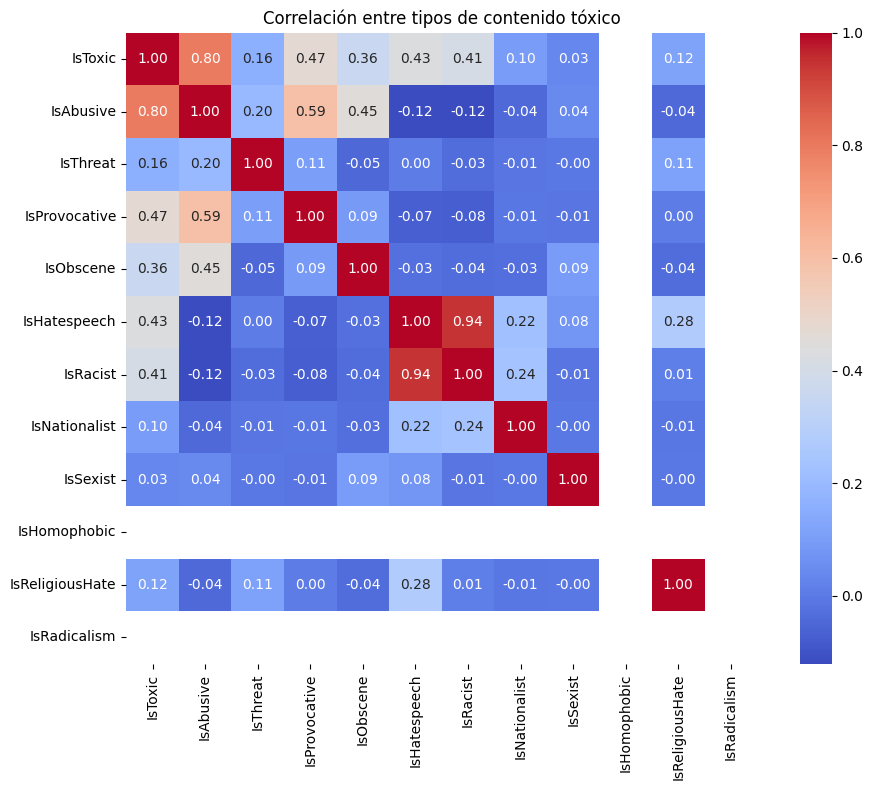

In [9]:
plt.figure(figsize=(10, 8))
corr = df[label_cols].astype(int).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlación entre tipos de contenido tóxico')
plt.tight_layout()
plt.show()

### Valores nulos

Verificamos la integridad del dataset antes de cualquier transformación.
Un dataset con valores nulos puede introducir errores silenciosos en el modelo.

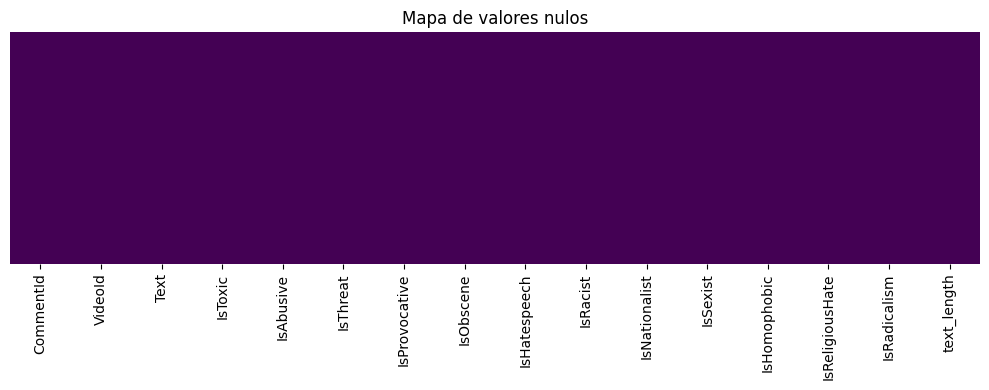

Total de valores nulos: 0


In [10]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de valores nulos')
plt.tight_layout()
plt.show()

print(f"Total de valores nulos: {df.isnull().sum().sum()}")

### Ejemplos reales del dataset

Revisamos comentarios reales para entender el tipo de lenguaje
que el modelo deberá aprender a identificar.

In [11]:
print("Ejemplos de comentarios TOXICOS:")
print("-" * 60)
for text in df[df['IsToxic'] == True]['Text'].sample(3, random_state=42).values:
    print(f"- {text}\n")

print("Ejemplos de comentarios NO TOXICOS:")
print("-" * 60)
for text in df[df['IsToxic'] == False]['Text'].sample(3, random_state=42).values:
    print(f"- {text}\n")

Ejemplos de comentarios TOXICOS:
------------------------------------------------------------
- whites are weak

- Masri is a total idiot "I don't have to know the evidence, I can just come to my own conclusions instead"
Here is a clue, dont attack a cop and try to take his gun and then rush him after he finally gets out of his car and you wont get shot duhhh.
So what would Masri do, take Brown out for a icecream as he is beating him into the ground and not defend himself?
BTW, Browns momma and gramma violently assaulted some people who were selling T-shirts in memory of Brown and put two people in the hospital, stole their money and trashed their shop and will probably be charged for it, so we all know what sort of mentality Brown was raised in and he was a thug wanna be, who caused his own death.

- Racial profiling and police intimidation? He robbed a store and got killed as a result. Fucking excuses man. Black people shouldn't have to get arrested when they commit a strong arm robb

### Estadísticas descriptivas del texto

Analizamos la longitud media, máxima y mínima de los comentarios
para entender el volumen de texto con el que trabajamos.

In [12]:
df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))

print("Estadísticas de longitud en caracteres:")
print(df.groupby('IsToxic')['text_length'].agg(['mean', 'min', 'max']).round(1))

print("\nEstadísticas de número de palabras:")
print(df.groupby('IsToxic')['word_count'].agg(['mean', 'min', 'max']).round(1))

Estadísticas de longitud en caracteres:
          mean  min   max
IsToxic                  
False    182.3    3  2292
True     189.4    6  4421

Estadísticas de número de palabras:
         mean  min  max
IsToxic                
False    33.1    1  418
True     34.6    1  815


### Observaciones sobre la calidad del etiquetado

Durante la revisión manual de ejemplos se detectaron inconsistencias en el etiquetado del dataset.
Algunos comentarios marcados como no tóxicos contienen lenguaje racialmente cargado o estereotipos,
mientras que algunos tóxicos son preguntas directas sin lenguaje explícitamente ofensivo.

**Causas probables:**
- Subjetividad inherente al proceso de anotación humana
- Sesgo del anotador según contexto cultural
- Tamaño reducido del dataset (1000 muestras)

**Implicación para el modelo:**
El modelo aprenderá los patrones del etiquetado incluyendo sus inconsistencias.
Esto es una limitación conocida que debe tenerse en cuenta al interpretar las métricas de evaluación.

### Validación de la etiqueta objetivo

Comparamos la etiqueta `IsToxic` original con una etiqueta reconstruida a partir
de las subcategorías para detectar inconsistencias en el etiquetado.

In [13]:
subcategories = ['IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene',
                 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
                 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

df['IsToxic_reconstructed'] = df[subcategories].any(axis=1)

print("Comparación entre etiqueta original y reconstruida:")
print(df[['IsToxic', 'IsToxic_reconstructed']].value_counts())

inconsistencies = df[df['IsToxic'] != df['IsToxic_reconstructed']]
print(f"\nTotal de inconsistencias encontradas: {len(inconsistencies)}")
print(f"Porcentaje sobre el total: {len(inconsistencies)/len(df)*100:.2f}%")

Comparación entre etiqueta original y reconstruida:
IsToxic  IsToxic_reconstructed
False    False                    538
True     True                     462
Name: count, dtype: int64

Total de inconsistencias encontradas: 0
Porcentaje sobre el total: 0.00%


In [14]:
df.drop(columns=['IsToxic_reconstructed'], inplace=True)

print("Etiqueta objetivo confirmada: IsToxic")
print(f"Distribucion final: {df['IsToxic'].value_counts().to_dict()}")

Etiqueta objetivo confirmada: IsToxic
Distribucion final: {False: 538, True: 462}


### Conclusión sobre la etiqueta objetivo

La comparación entre `IsToxic` y la etiqueta reconstruida desde las subcategorías
arroja 0 inconsistencias. Esto confirma que el dataset es internamente coherente:
`IsToxic` es exactamente equivalente a la unión de todas las subcategorías.

El problema detectado en la revisión manual no es inconsistencia sino **subjetividad
en los criterios de anotación**. Los límites entre tóxico y no tóxico dependen
del criterio del anotador, no de un error en el etiquetado.

**Decisión:** se mantiene `IsToxic` como etiqueta objetivo sin modificaciones.